# Exercise 2 — ML Key Challenges


In this exercise, you will train several models and observe three cases:

1. Underfitting — model too simple
2. Good fit — model captures the pattern
3. Overfitting — model memorizes the noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


Create synthetic nonlinear data

In [2]:
np.random.seed(42)

X = np.linspace(0, 10, 80).reshape(-1, 1)

y_true = np.sin(X).ravel()

y = y_true + np.random.normal(0, 0.25, size=y_true.shape)


Train / test split

In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# For smooth plotting
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)

In [4]:
models = [
    {"degree": 1, "name": "Model A"},
    {"degree": 4, "name": "Model B"},
    {"degree": 15, "name": "Model C"},
]

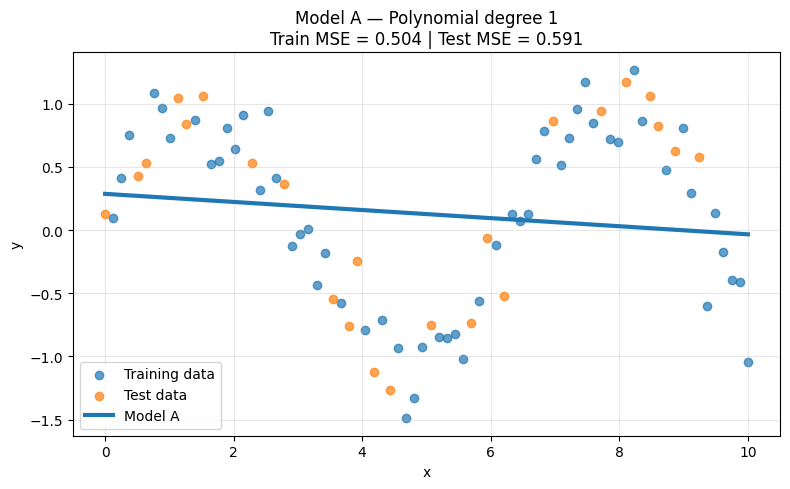

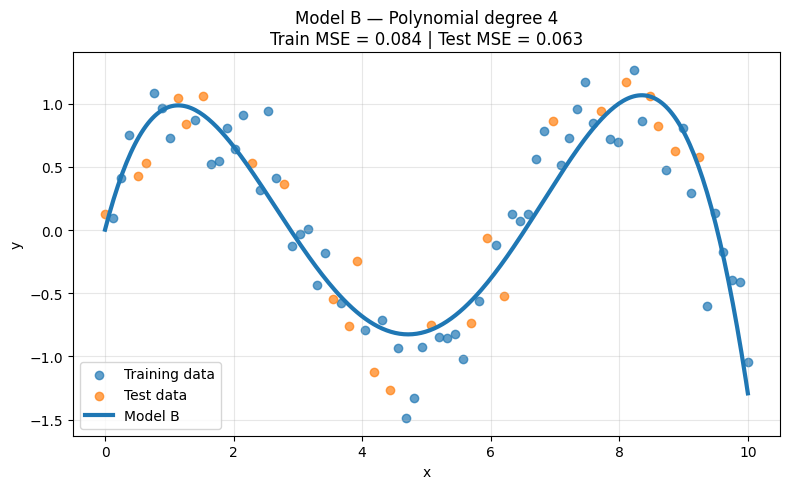

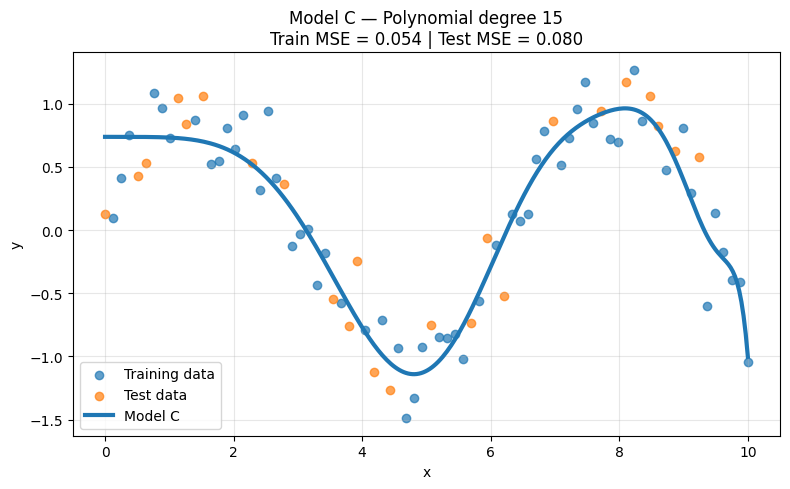

In [6]:
for item in models:
    degree = item["degree"]

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_plot = model.predict(x_plot)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    plt.figure(figsize=(8, 5))

    plt.scatter(X_train, y_train, alpha=0.7, label="Training data")
    plt.scatter(X_test, y_test, alpha=0.7, label="Test data")
    plt.plot(x_plot, y_plot, linewidth=3, label=item["name"])

    plt.title(
        f"{item['name']} — Polynomial degree {degree}\n"
        f"Train MSE = {train_mse:.3f} | Test MSE = {test_mse:.3f}"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Questions

1. Which model is underfitting?
2. Which model is overfitting?
3. Which model generalizes best?
4. How do you know from the plot?
5. How do you know from the train/test MSE?

In [ ]:
#1. the first model is underfitting

In [ ]:
#2 the third model is overfitting

In [ ]:
#3 the second model generalizes the best, it follows both the test data and the real datas.

In [ ]:
# the model A has a very simple residual line 
# when comparing the second and the third one, I noted that for the model B covered the test data from 0 to 2 in x-axis better than the model C.
# in the model C, at around x = [4, 6], it could indicate the overfitting problem due to it memorized the noises, similar thing at x = 10

In [ ]:
#numbers are really easy to indicate, 
# if the model has relatative similar MSE of trainning and test, it could indicate that the model is underfitting (model A)
# if the model has relatively worse trainning MSE but good/best test MSE then we can say that the model generalizes the best (model B)
# if tranning MSE < testing MSE but the difference between MSE are big then the model is overfitting (best trainning MSE but worst test MSE) (model C)